# Sea Surface Temperature (SST) Indonesia 2021-2025
**Author:** Ikhsan Mustaqim | github.com/ikhsanaqim | linkedin.com/in/ikhsanaqim

**Data:** NOAA OISST v2.1 - Huang et al. (2021), DOI: 10.1175/JCLI-D-20-0166.1

**Output files:**
- `sst_YYYY.png` - individual journal map per tahun (300 DPI)
- `sst_anomaly_2024_linkedin.png` - anomaly map 2024 (12x6 inch)
- `sst_interactive_2024.html` - interactive Plotly map (no token)
- `sst_timeseries_2021_2025.html` - time-series chart


In [1]:
!pip install cartopy --quiet
print("Done")

Done


In [2]:
# CELL 2: Imports & Global Style
import numpy as np
import pandas as pd
import xarray as xr
import requests, io, base64
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.gridspec import GridSpec
from PIL import Image as PILImage
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'figure.dpi'       : 100,
    'savefig.dpi'      : 300,
    'axes.linewidth'   : 0.8,
    'figure.facecolor' : 'white',
})
print('Library & style siap')


Library & style siap


In [3]:
# CELL 3: Konfigurasi & Download NOAA OISST
# Menggunakan 2 server ERDDAP sebagai fallback jika salah satu tidak bisa diakses
import time

LAT_MIN, LAT_MAX = -11.0,  6.0
LON_MIN, LON_MAX =  95.0, 141.0
YEARS   = [2021, 2022, 2023, 2024, 2025]

# Dua server ERDDAP resmi NOAA — keduanya berisi data yang sama
ERDDAP_SERVERS = [
    {
        'url'     : 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg_LonPM180.nc',
        'name'    : 'PFEG CoastWatch',
        'var'     : 'sst',
        'lon_pm180': True   # longitude -180 to 180
    },
    {
        'url'     : 'https://www.ncei.noaa.gov/erddap/griddap/ncdc_oisst_v2_avhrr_by_time_zlev_lat_lon.nc',
        'name'    : 'NCEI (backup)',
        'var'     : 'sst',
        'lon_pm180': False  # longitude 0 to 360
    },
]

def build_query(server, year):
    """Build ERDDAP griddap URL query untuk satu tahun."""
    t1 = str(year) + '-01-01T12:00:00Z'
    t2 = str(year) + '-12-31T12:00:00Z'
    if server['lon_pm180']:
        lon1, lon2 = str(LON_MIN), str(LON_MAX)
    else:
        # NCEI menggunakan 0-360, konversi jika perlu
        lon1 = str(LON_MIN + 360) if LON_MIN < 0 else str(LON_MIN)
        lon2 = str(LON_MAX)
    q = (server['var'] + '[(' + t1 + '):15:(' + t2 + ')]'
         '[(0.0):1:(0.0)]'
         '[(' + str(LAT_MIN) + '):1:(' + str(LAT_MAX) + ')]'
         '[(' + lon1 + '):1:(' + lon2 + ')]')
    return server['url'] + '?' + q

def download_year(year, max_retries=3):
    """
    Download NOAA OISST satu tahun.
    Mencoba server primary dulu, lalu fallback ke server backup.
    Setiap server dicoba max_retries kali sebelum pindah ke server berikutnya.
    """
    for server in ERDDAP_SERVERS:
        for attempt in range(1, max_retries + 1):
            try:
                url = build_query(server, year)
                r   = requests.get(url, timeout=180)
                r.raise_for_status()
                ds  = xr.open_dataset(io.BytesIO(r.content))
                sst = ds['sst'].squeeze('zlev').resample(time='1ME').mean()
                # Pastikan longitude dalam range yang benar untuk plotting
                if not server['lon_pm180']:
                    # Konversi 0-360 ke -180 ke 180 jika perlu
                    lon = sst.longitude.values
                    if lon.max() > 180:
                        sst = sst.assign_coords(longitude=((lon + 180) % 360) - 180)
                        sst = sst.sortby('longitude')
                server_name = server['name']
                print('  ' + str(year) + ' [' + server_name + ']: '
                      + str(len(sst.time)) + ' bulan, shape ' + str(sst.shape))
                return sst
            except Exception as e:
                err_short = str(e)[:80]
                print('  ' + str(year) + ' attempt ' + str(attempt)
                      + '/' + str(max_retries) + ' (' + server['name'] + '): '
                      + err_short)
                if attempt < max_retries:
                    time.sleep(3 * attempt)  # backoff: 3s, 6s, 9s
    raise RuntimeError('Semua server ERDDAP tidak bisa diakses untuk tahun ' + str(year)
                       + '. Coba jalankan cell ini lagi setelah beberapa menit.')

print('Downloading NOAA OISST 2021-2025...')
print('(Jika server utama gagal, otomatis fallback ke server NCEI)')
print()

annual = {}
for y in YEARS:
    annual[y] = download_year(y)

da_all   = xr.concat([annual[y] for y in YEARS], dim='time')
ann_mean = {y: annual[y].mean(dim='time') for y in YEARS}

ts_df          = da_all.mean(dim=['latitude','longitude']).to_dataframe(name='sst').reset_index()
ts_df['year']  = ts_df['time'].dt.year
ts_df['month'] = ts_df['time'].dt.month

# Hitung baseline & anomali (dipakai di Cell 7 & Cell 10)
sst_clim  = xr.concat([ann_mean[y] for y in YEARS], dim='year').mean(dim='year')
anomalies = {y: ann_mean[y] - sst_clim for y in YEARS}

print()
print('Selesai: ' + str(len(da_all.time)) + ' timestep total')


(Jika server utama gagal, otomatis fallback ke server NCEI)

  2021 [PFEG CoastWatch]: 12 bulan, shape (12, 69, 185)
  2022 [PFEG CoastWatch]: 12 bulan, shape (12, 69, 185)
  2023 [PFEG CoastWatch]: 12 bulan, shape (12, 69, 185)
  2024 [PFEG CoastWatch]: 12 bulan, shape (12, 69, 185)
  2025 [PFEG CoastWatch]: 12 bulan, shape (12, 69, 185)

Selesai: 60 timestep total


In [4]:
# CELL 4: Statistik Deskriptif
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('='*55)
print('STATISTICS: SST INDONESIAN WATERS 2021-2025')
print('='*55)
for y in YEARS:
    v = ann_mean[y].values.flatten()
    v = v[~np.isnan(v)]
    print(str(y) + ': Mean=' + str(round(v.mean(),3))
          + ' C  Std=' + str(round(v.std(),3))
          + ' C  Min=' + str(round(v.min(),2))
          + ' C  Max=' + str(round(v.max(),2)) + ' C')

delta    = float(np.nanmean(ann_mean[2024].values)) - float(np.nanmean(ann_mean[2021].values))
anom_24  = anomalies[2024].values.flatten()
anom_24  = anom_24[~np.isnan(anom_24)]
pct_warm = np.sum(anom_24 > 0) / len(anom_24) * 100
mc       = ts_df.groupby('month')['sst'].mean()

print()
print('SST change (2021->2024) : ' + str(round(delta, 4)) + ' C')
print('% area warmer (2024)    : ' + str(round(pct_warm, 1)) + '%')
print('Warmest month (5-yr avg): ' + MONTHS[mc.idxmax()-1] + ' (' + str(round(mc.max(),2)) + ' C)')
print('Coldest month (5-yr avg): ' + MONTHS[mc.idxmin()-1] + ' (' + str(round(mc.min(),2)) + ' C)')
print('Climatology baseline    : ' + str(round(float(sst_clim.mean()),3)) + ' C')
print('='*55)


STATISTICS: SST INDONESIAN WATERS 2021-2025
2021: Mean=29.198 C  Std=0.528 C  Min=27.88 C  Max=30.2 C
2022: Mean=29.286 C  Std=0.444 C  Min=28.11 C  Max=30.23 C
2023: Mean=28.997 C  Std=0.659 C  Min=26.41 C  Max=30.3 C
2024: Mean=29.354 C  Std=0.535 C  Min=27.67 C  Max=30.61 C
2025: Mean=29.239 C  Std=0.507 C  Min=28.01 C  Max=30.26 C

SST change (2021->2024) : 0.1557 C
% area warmer (2024)    : 74.7%
Warmest month (5-yr avg): May (29.79 C)
Coldest month (5-yr avg): Aug (28.52 C)
Climatology baseline    : 29.215 C


In [5]:
# CELL 5: Helper — Single Panel Journal Map
PROJ       = ccrs.PlateCarree()
EXTENT     = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
CMAP       = 'RdYlBu_r'
VMIN, VMAX = 24.5, 31.5

def make_single_map(data, title, subtitle,
                    cmap=CMAP, vmin=VMIN, vmax=VMAX,
                    cbar_label='SST (C)',
                    panel_label='(a)', filename=None):
    """Render satu panel peta journal-quality dan simpan ke file PNG."""
    fig = plt.figure(figsize=(7, 4.2))
    ax  = fig.add_subplot(1, 1, 1, projection=PROJ)
    ax.set_extent(EXTENT, crs=PROJ)

    pcm = ax.pcolormesh(
        data.longitude, data.latitude, data.values,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=PROJ, rasterized=True
    )
    ax.add_feature(cfeature.LAND,      facecolor='#EBEBEB', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#2C2C2C', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='#555',
                   linestyle=':', zorder=3)

    gl = ax.gridlines(crs=PROJ, draw_labels=True,
                      linewidth=0.4, color='#AAAAAA', alpha=0.8, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlocator   = mticker.FixedLocator([100, 110, 120, 130, 140])
    gl.ylocator   = mticker.FixedLocator([-10, -5, 0, 5])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8, 'color': '#333'}
    gl.ylabel_style = {'size': 8, 'color': '#333'}

    ax.set_title(title + chr(10) + subtitle, fontsize=11, fontweight='bold', pad=5)
    ax.text(0.02, 0.97, panel_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5))

    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal',
                        pad=0.08, shrink=0.75, aspect=30)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_linewidth(0.8)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print('  Saved: ' + filename)
    plt.show()
    plt.close()

print('Helper siap')


Helper siap


Membuat peta per tahun...
  Saved: sst_2021.png


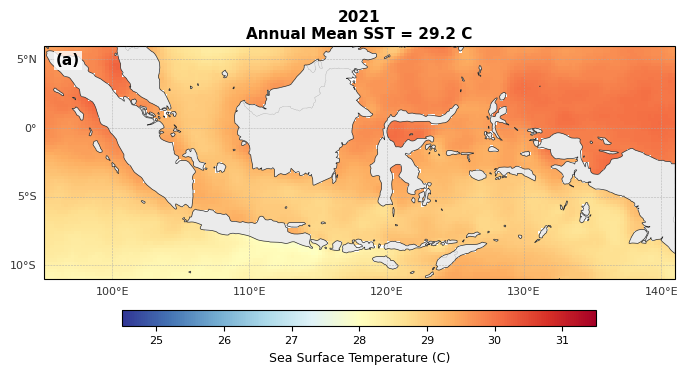

  Saved: sst_2022.png


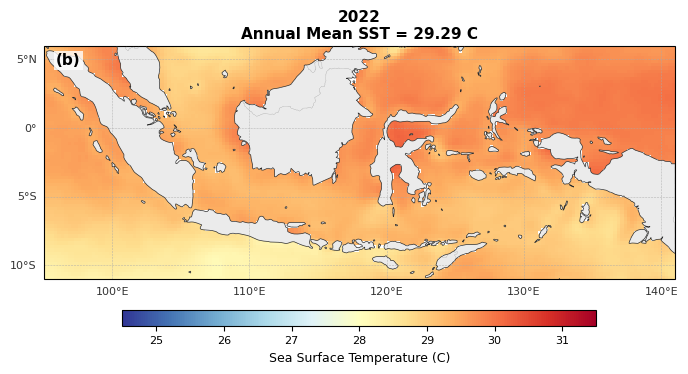

  Saved: sst_2023.png


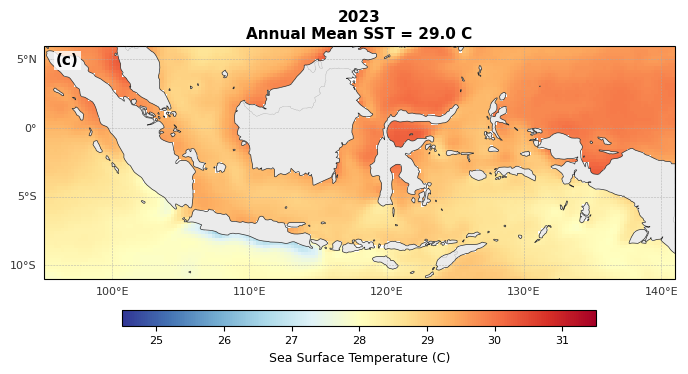

  Saved: sst_2024.png


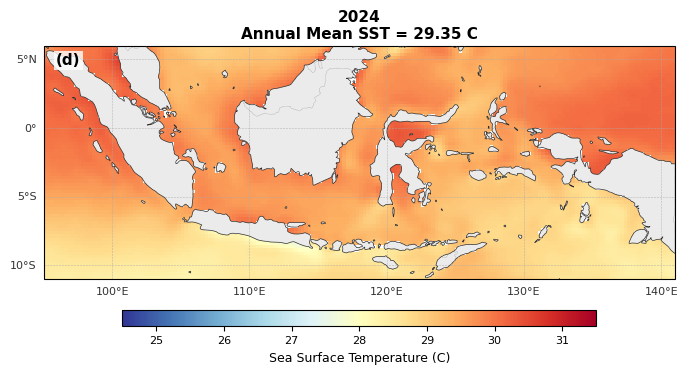

  Saved: sst_2025.png


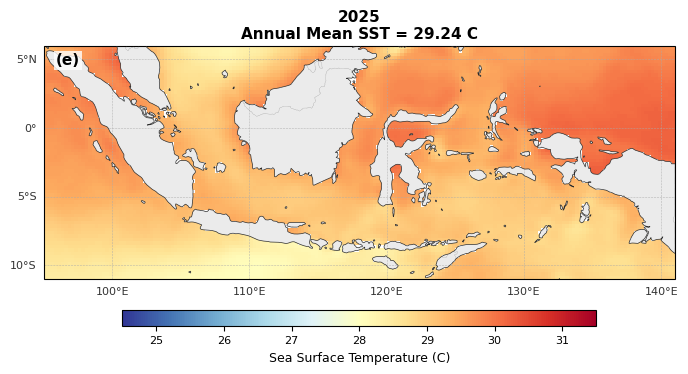

Selesai: 5 peta tahunan tersimpan


In [6]:
# CELL 6: Render Individual SST Maps per Tahun
print('Membuat peta per tahun...')
PANEL = ['(a)', '(b)', '(c)', '(d)', '(e)']

for i, y in enumerate(YEARS):
    v = ann_mean[y].values.flatten()
    v = v[~np.isnan(v)]
    make_single_map(
        data        = ann_mean[y],
        title       = str(y),
        subtitle    = 'Annual Mean SST = ' + str(round(v.mean(), 2)) + ' C',
        cbar_label  = 'Sea Surface Temperature (C)',
        panel_label = PANEL[i],
        filename    = 'sst_' + str(y) + '.png'
    )

print('Selesai: 5 peta tahunan tersimpan')


Anomali 2024: 0.139 C
% area warmer: 74.7%
Climatology  : 29.215 C


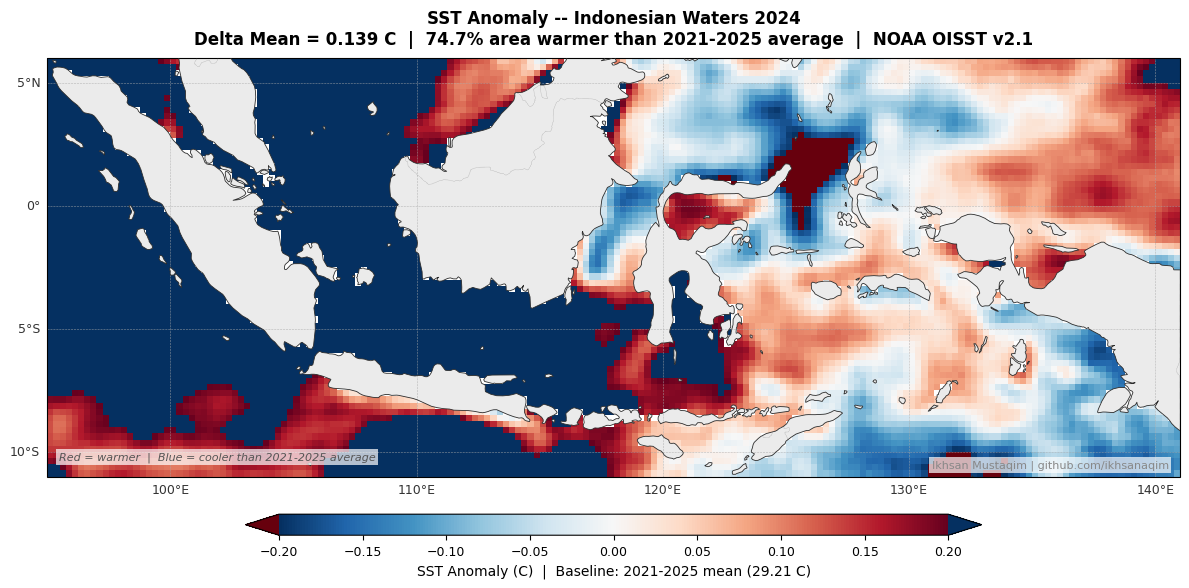

Saved: sst_anomaly_2024_linkedin.png (12x6 inch, 300 DPI)


In [7]:
# CELL 7: Anomaly Map 2024 vs Climatology — LinkedIn Size
YEAR_ANOM = 2024
anom      = anomalies[YEAR_ANOM]
anom_mean = float(np.nanmean(anom.values))
anom_vals = anom.values.flatten()
anom_vals = anom_vals[~np.isnan(anom_vals)]
pct_warm  = np.sum(anom_vals > 0) / len(anom_vals) * 100
clim_mean = float(sst_clim.mean())

print('Anomali ' + str(YEAR_ANOM) + ': ' + str(round(anom_mean, 3)) + ' C')
print('% area warmer: ' + str(round(pct_warm, 1)) + '%')
print('Climatology  : ' + str(round(clim_mean, 3)) + ' C')

ANOM_LIM  = 0.20
cmap_anom = plt.cm.RdBu_r.copy()
cmap_anom.set_under('#67000d')
cmap_anom.set_over('#053061')

fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw={'projection': PROJ})
ax.set_extent(EXTENT, crs=PROJ)

pcm = ax.pcolormesh(
    anom.longitude, anom.latitude, anom.values,
    cmap=cmap_anom, vmin=-ANOM_LIM, vmax=ANOM_LIM,
    transform=PROJ, rasterized=True
)
ax.add_feature(cfeature.LAND,      facecolor='#EBEBEB', edgecolor='none', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='#2C2C2C', zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='#666',
               linestyle=':', zorder=3)

gl = ax.gridlines(crs=PROJ, draw_labels=True,
                  linewidth=0.4, color='#AAAAAA', alpha=0.8, linestyle='--')
gl.top_labels = gl.right_labels = False
gl.xlocator   = mticker.FixedLocator([100, 110, 120, 130, 140])
gl.ylocator   = mticker.FixedLocator([-10, -5, 0, 5])
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 9, 'color': '#333'}
gl.ylabel_style = {'size': 9, 'color': '#333'}

cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal',
                    pad=0.07, shrink=0.65, aspect=35, extend='both')
cbar.set_label(
    'SST Anomaly (C)  |  Baseline: 2021-2025 mean (' + str(round(clim_mean, 2)) + ' C)',
    fontsize=10
)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.8)

nl = chr(10)
line1 = 'SST Anomaly -- Indonesian Waters ' + str(YEAR_ANOM)
line2 = ('Delta Mean = ' + str(round(anom_mean, 3)) + ' C  |  '
         + str(round(pct_warm, 1)) + '% area warmer than 2021-2025 average  |  NOAA OISST v2.1')
ax.set_title(line1 + nl + line2, fontsize=12, fontweight='bold', pad=10)

ax.text(0.01, 0.04, 'Red = warmer  |  Blue = cooler than 2021-2025 average',
        transform=ax.transAxes, fontsize=8, color='#555', style='italic',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
ax.text(0.99, 0.02, 'Ikhsan Mustaqim | github.com/ikhsanaqim',
        transform=ax.transAxes, fontsize=8, color='#888', ha='right',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

plt.tight_layout()
outfile = 'sst_anomaly_' + str(YEAR_ANOM) + '_linkedin.png'
plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
plt.close()
print('Saved: ' + outfile + ' (12x6 inch, 300 DPI)')


In [8]:
# CELL 8: Interactive Map — Plotly Mapbox Image Overlay (No Token)
YEAR_INTERACTIVE = 2024
sst_da           = ann_mean[YEAR_INTERACTIVE]

# SST array -> RGBA PNG -> base64 untuk Plotly image layer
sst_flip = np.flipud(sst_da.values)   # flip: xarray lat S->N, mapbox butuh N->S
norm     = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
rgba     = cm.get_cmap(CMAP)(norm(sst_flip))
rgba[np.isnan(sst_flip), 3] = 0.0    # NaN = transparan (daratan)
img_arr  = (rgba * 255).astype(np.uint8)

buf     = io.BytesIO()
PILImage.fromarray(img_arr, mode='RGBA').save(buf, format='PNG')
img_src = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode('utf-8')

# 4 corner coordinates: [lon, lat] clockwise from NW
coords = [
    [LON_MIN, LAT_MAX], [LON_MAX, LAT_MAX],
    [LON_MAX, LAT_MIN], [LON_MIN, LAT_MIN],
]

# Marker lokasi utama
LOCS = [
    (-2.5, 112.0, 'Laut Jawa'),    ( 3.0, 108.0, 'Laut Natuna'),
    (-5.0, 130.0, 'Laut Banda'),   ( 1.0, 126.0, 'Laut Maluku'),
    (-8.5, 115.5, 'Bali'),         ( 2.0, 119.0, 'Selat Makassar'),
    (-6.0, 105.5, 'Selat Sunda'), (-1.0, 136.0, 'Papua'),
]
df_sst = sst_da.to_dataframe(name='sst').reset_index().dropna(subset=['sst'])
loc_lats, loc_lons, loc_names, loc_sst = [], [], [], []
for lat, lon, nama in LOCS:
    idx = (df_sst['latitude'].sub(lat).abs() + df_sst['longitude'].sub(lon).abs()).idxmin()
    loc_lats.append(lat); loc_lons.append(lon)
    loc_names.append(nama); loc_sst.append(round(df_sst.loc[idx, 'sst'], 2))

fig_map = go.Figure()
fig_map.add_trace(go.Scattermapbox(    # dummy trace untuk init mapbox
    lat=[0], lon=[120], mode='markers',
    marker=dict(size=1, opacity=0), showlegend=False, hoverinfo='skip'
))
hover_list = ['<b>' + n + '</b><br>SST ' + str(YEAR_INTERACTIVE)
              + ': <b>' + str(s) + ' C</b><extra></extra>'
              for n, s in zip(loc_names, loc_sst)]
fig_map.add_trace(go.Scattermapbox(
    lat=loc_lats, lon=loc_lons, mode='markers+text',
    marker=dict(size=10, color='white', opacity=0.95),
    text=loc_names, textposition='top right',
    textfont=dict(size=10, color='white'),
    hovertemplate=hover_list, name='Lokasi', showlegend=False
))

map_title = ('SST Indonesian Waters ' + str(YEAR_INTERACTIVE)
             + '<br><sup>Annual Mean | NOAA OISST v2.1 | '
             + str(VMIN) + '-' + str(VMAX) + ' C | Ikhsan Mustaqim</sup>')
fig_map.update_layout(
    mapbox=dict(
        style='carto-darkmatter', center=dict(lat=-2, lon=118), zoom=3.8,
        layers=[dict(sourcetype='image', source=img_src,
                     coordinates=coords, opacity=0.82, below='traces')]
    ),
    title=dict(text=map_title, font=dict(size=14, color='white'), x=0.5),
    paper_bgcolor='#1a1a2e',
    margin=dict(t=80, b=10, l=10, r=10), height=580,
)
outfile = 'sst_interactive_' + str(YEAR_INTERACTIVE) + '.html'
fig_map.write_html(outfile, include_plotlyjs='cdn')
fig_map.show()
print('Saved: ' + outfile)


Saved: sst_interactive_2024.html


In [9]:
# CELL 9: Time-Series SST 2021-2025 (Plotly)
COLORS = {2021:'#2980B9', 2022:'#27AE60', 2023:'#E67E22', 2024:'#8E44AD', 2025:'#E74C3C'}

fig_ts = go.Figure()
for y in YEARS:
    df_y = ts_df[ts_df['year']==y].sort_values('time')
    fig_ts.add_trace(go.Scatter(
        x=df_y['time'], y=df_y['sst'],
        mode='lines+markers', name=str(y),
        line=dict(color=COLORS[y], width=2.5), marker=dict(size=6),
        hovertemplate='<b>' + str(y) + '</b><br>%{x|%b %Y}<br>SST: %{y:.3f} C<extra></extra>'
    ))

for yr in [2021, 2022, 2023, 2024]:
    fig_ts.add_vrect(
        x0=str(yr)+'-12-01', x1=str(yr+1)+'-03-01',
        fillcolor='#3498DB', opacity=0.07, layer='below', line_width=0,
        annotation_text='West Monsoon' if yr==2021 else '',
        annotation_position='top left',
        annotation_font_color='#3498DB', annotation_font_size=9
    )

d21 = ts_df[ts_df['year']==2021]['sst'].mean()
d24 = ts_df[ts_df['year']==2024]['sst'].mean()
delta_str = str(round(float(d24-d21), 3))

fig_ts.update_layout(
    title=dict(text=('Sea Surface Temperature -- Indonesian Waters (2021-2025)<br>'
                     '<sup>Spatially averaged monthly mean | Delta(2021->2024): '
                     + delta_str + ' C | NOAA OISST v2.1 | Ikhsan Mustaqim</sup>'),
               font=dict(size=14)),
    xaxis=dict(title='Time', showgrid=True, gridcolor='rgba(200,200,200,.2)',
               tickformat='%b %Y', tickangle=-30),
    yaxis=dict(title='SST (C)', showgrid=True, gridcolor='rgba(200,200,200,.2)'),
    legend=dict(title='Year', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    plot_bgcolor='#F8F9FA', paper_bgcolor='white',
    font=dict(color='#2C3E50'), hovermode='x unified', height=460
)
fig_ts.write_html('sst_timeseries_2021_2025.html', include_plotlyjs='cdn')
fig_ts.show()
print('Saved: sst_timeseries_2021_2025.html')


Saved: sst_timeseries_2021_2025.html


In [10]:
# CELL 10: Summary
print('='*55)
print('OUTPUT FILES')
print('='*55)
for y in YEARS:
    v = ann_mean[y].values.flatten()
    v = v[~np.isnan(v)]
    print('  sst_' + str(y) + '.png  ->  Mean: ' + str(round(v.mean(),3)) + ' C')
print('  sst_anomaly_2024_linkedin.png  (12x6 inch, 300 DPI)')
print('  sst_interactive_2024.html  (Plotly image overlay)')
print('  sst_timeseries_2021_2025.html')
print()
print('KEY NUMBERS FOR LINKEDIN:')
d21     = float(np.nanmean(ann_mean[2021].values))
d24     = float(np.nanmean(ann_mean[2024].values))
anom_v  = anomalies[2024].values.flatten()
anom_v  = anom_v[~np.isnan(anom_v)]
pct_w   = np.sum(anom_v > 0) / len(anom_v) * 100
mc      = ts_df.groupby('month')['sst'].mean()
nov24   = ts_df[(ts_df.year==2024) & (ts_df.month==11)]['sst'].values
print('  SST change (2021->2024): ' + str(round(d24-d21, 4)) + ' C')
print('  % area warmer (2024)   : ' + str(round(pct_w, 1)) + '%')
print('  Warmest month (5-yr)   : ' + MONTHS[mc.idxmax()-1])
print('  Coldest month (5-yr)   : ' + MONTHS[mc.idxmin()-1])
if len(nov24) > 0:
    print('  Nov 2024 peak SST      : ' + str(round(float(nov24[0]), 2)) + ' C')
print()
print('CITATION: Huang et al. (2021). DOI: 10.1175/JCLI-D-20-0166.1')


OUTPUT FILES
  sst_2021.png  ->  Mean: 29.198 C
  sst_2022.png  ->  Mean: 29.286 C
  sst_2023.png  ->  Mean: 28.997 C
  sst_2024.png  ->  Mean: 29.354 C
  sst_2025.png  ->  Mean: 29.239 C
  sst_anomaly_2024_linkedin.png  (12x6 inch, 300 DPI)
  sst_interactive_2024.html  (Plotly image overlay)
  sst_timeseries_2021_2025.html

KEY NUMBERS FOR LINKEDIN:
  SST change (2021->2024): 0.1557 C
  % area warmer (2024)   : 74.7%
  Warmest month (5-yr)   : May
  Coldest month (5-yr)   : Aug
  Nov 2024 peak SST      : 30.07 C

CITATION: Huang et al. (2021). DOI: 10.1175/JCLI-D-20-0166.1
